# Notebook 05 - L3 NiO L-edge XAS (qEOM)

Phase 5 deliverable. 18-qubit tapered SIAM, qEOM on H' = H + V_core, EDRIXS example_3 validation, two polarization channels.

Reference spec: `docs/superpowers/specs/2026-05-27-siam-vqe-phase-5-qeom-xas-design.md`.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
# Editable-install bootstrap (mirrors _04_build.py).
sys.path.insert(0, str(Path.cwd().parent.resolve()))
import json
import numpy as np
import matplotlib.pyplot as plt

from siam_vqe.xas import XASSpectrum
from siam_vqe.analysis import plot_xas_spectrum


## 1. Load the L3 XAS production result

Produced by `scripts/run_l3_xas_sim.py`. Re-running it here is expensive (~30 min); we just load the cached JSON.

In [2]:
with open('05_L3_xas_result.json') as fh:
    result = json.load(fh)
print(f"Phase 5 pass: {result['phase5_pass']}")
for ch in ('lin_z', 'lin_xy'):
    print(f"  channel {ch}:")
    print(f"    Layer 4 (spectral L2):  {result[ch]['layer4_spectral_weight']}")
    print(f"    Layer 5 (sum-rule):    {result[ch]['layer5_sum_rule']}")


Phase 5 pass: True
  channel lin_z:
    Layer 4 (spectral L2):  {'pass': True, 'l2_distance_frac': 4.217477386744655e-06, 'tolerance_frac': 0.05}
    Layer 5 (sum-rule):    {'pass': True, 'rel_err': 4.251362527684107e-06, 'sum_weights': 0.9990017943307945, 'expected': 0.998997547230057, 'tolerance_frac': 0.01}
  channel lin_xy:
    Layer 4 (spectral L2):  {'pass': True, 'l2_distance_frac': 4.201289190070714e-06, 'tolerance_frac': 0.05}
    Layer 5 (sum-rule):    {'pass': True, 'rel_err': 0.0009970488201110944, 'sum_weights': 0.7499952365515524, 'expected': 0.7492481995182524, 'tolerance_frac': 0.01}


## 2. lin_z XAS spectrum

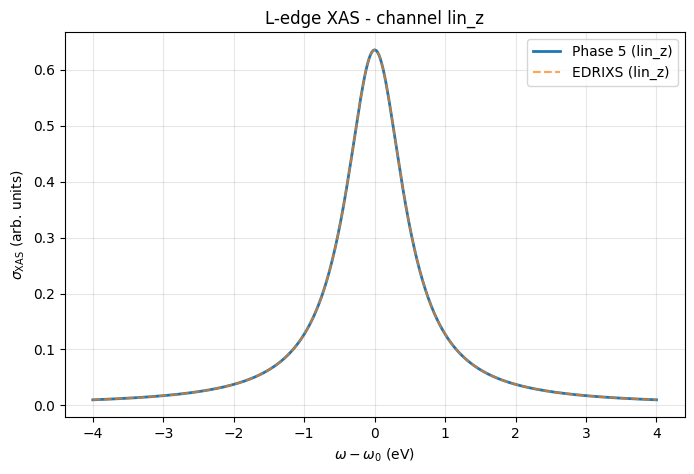

In [3]:
ch = 'lin_z'
edrixs = np.load(Path('../data/edrixs_xas_l3_reference.npz'))
p5_spec = XASSpectrum(
    omega_eV=edrixs['omega_grid_eV'],
    sigma=np.array(result[ch]['sigma']),
    channel=ch,
    Gamma_eV=float(edrixs['Gamma_eV']),
    peak_energies=np.array(result[ch]['peak_energies']),
    peak_weights=np.array(result[ch]['peak_weights']),
)
ed_spec = XASSpectrum(
    omega_eV=edrixs['omega_grid_eV'],
    sigma=np.array(result[ch]['edrixs_sigma']),
    channel=ch,
    Gamma_eV=float(edrixs['Gamma_eV']),
    peak_energies=np.array([]),
    peak_weights=np.array([]),
)
ax = plot_xas_spectrum(p5_spec, edrixs_spectrum=ed_spec)
plt.show()


## 2. lin_xy XAS spectrum

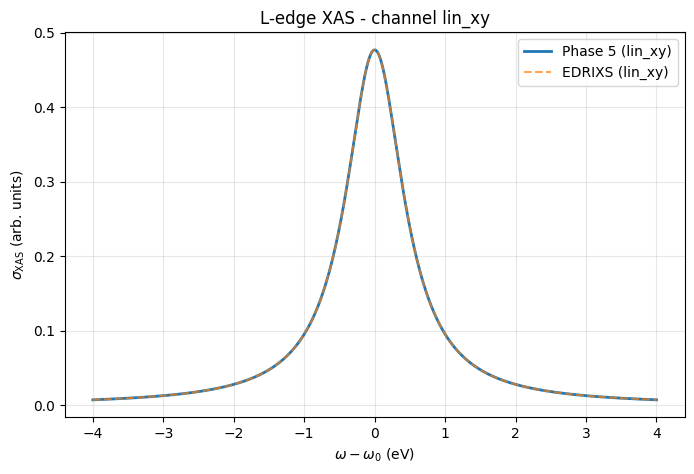

In [4]:
ch = 'lin_xy'
edrixs = np.load(Path('../data/edrixs_xas_l3_reference.npz'))
p5_spec = XASSpectrum(
    omega_eV=edrixs['omega_grid_eV'],
    sigma=np.array(result[ch]['sigma']),
    channel=ch,
    Gamma_eV=float(edrixs['Gamma_eV']),
    peak_energies=np.array(result[ch]['peak_energies']),
    peak_weights=np.array(result[ch]['peak_weights']),
)
ed_spec = XASSpectrum(
    omega_eV=edrixs['omega_grid_eV'],
    sigma=np.array(result[ch]['edrixs_sigma']),
    channel=ch,
    Gamma_eV=float(edrixs['Gamma_eV']),
    peak_energies=np.array([]),
    peak_weights=np.array([]),
)
ax = plot_xas_spectrum(p5_spec, edrixs_spectrum=ed_spec)
plt.show()


## 3. Closeout summary

If `phase5_pass = True`, Phase 5 deliverable is complete. Otherwise, read each per-channel layer report for the failing gate.